## Inicjalizacja

In [51]:
!pip install -U optuna

In [52]:
from sklearn.datasets import make_moons
from typing import Tuple, List
from sklearn.metrics import auc
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, random_split, TensorDataset
import os
from tqdm.notebook import tqdm
import optuna
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

import optuna
print(optuna.__version__)


!nvidia-smi
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.manual_seed(42)

4.6.0
/bin/bash: line 1: nvidia-smi: command not found


## MLP

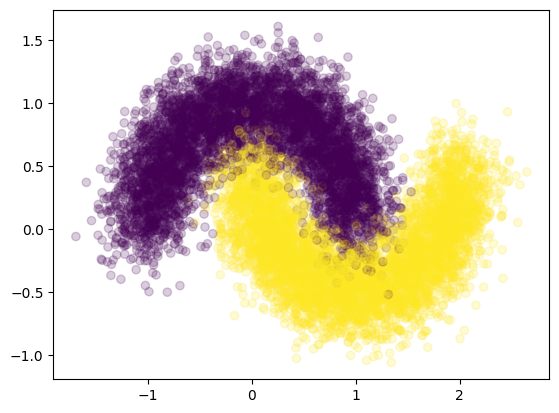

In [53]:
whole_moons = make_moons(n_samples=10000, noise=0.2, random_state=42)
plt.scatter(whole_moons[0][:, 0], whole_moons[0][:, 1], c=whole_moons[1], alpha=0.2)

In [54]:
print(whole_moons[0].shape[0])
print(whole_moons[0].shape[1])
print(whole_moons[1].shape)
print(whole_moons[0][0])
print(whole_moons[0][1])
print(whole_moons[1][0])


10000
2
(10000,)
[ 0.61709259 -0.04290016]
[-0.42796479 -0.11405297]
1


In [64]:
class MLPClassifier(nn.Module):
    def __init__(self, depth:int = 7, input_dim:int = 2, hidden_dim:int = 64, out_dim:int = 1):
        super().__init__()
        
        if depth < 2:
            raise ValueError("DEPTH < 2")
        
        last_hidden_dim: int = max(hidden_dim // 2, out_dim * 2) 
        hidden_sizes: list[int] = np.linspace(
            start=hidden_dim, 
            stop=last_hidden_dim, 
            num=depth - 1, 
            dtype=int
        ).tolist()
        layer_dims: list[int] = [input_dim] + hidden_sizes

        layers : list[nn.Module] = []
        layers.append(nn.Flatten())
        
        for i in range(len(layer_dims) - 1):
            layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(nn.ReLU())
            
        self.seq: nn.Sequential = nn.Sequential(*layers)
        
        self.head: nn.Linear = nn.Linear(layer_dims[-1], out_dim)
    
    def forward(self, x: torch.Tensor, embedding_flag: bool = False) -> torch.Tensor:
        features: torch.Tensor = self.seq(x)
        if embedding_flag:
            return features
        return self.head(features)
    
    def extract(self, Loader:DataLoader) -> Tuple[np.ndarray, np.ndarray]:
        embeddings: list[torch.Tensor] = []
        labels: list[torch.Tensor] = []
        
        self.eval() 
        with torch.no_grad():
            for X, y in Loader:
                X = X.to(DEVICE)
                emb: torch.Tensor = self.forward(X, embeddingFlag=True)
                embeddings.append(emb.cpu())
                labels.append(y.cpu())
        embeddings: np.ndarray = torch.cat(embeddings, dim=0).numpy()
        labels:np. ndarray = torch.cat(labels, dim=0).numpy()
        return embeddings, labels

In [65]:
model: nn.Module = MLPClassifier()
model.to(DEVICE)
loss: nn.Module = nn.BCEWithLogitsLoss()
optimizer: torch.optim.Optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [66]:
def train(loader: DataLoader, model: nn.Module, loss_fn: nn.Module , optimizer: torch.optim.Optimizer):
    size: int = len(loader.dataset)
    model.train()
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(DEVICE), y.to(DEVICE)

        pred: torch.Tensor = model(X)
        loss: torch.Tensor = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss = loss.item()
            current : int = (batch + 1) * len(X)
            print(f"train loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [67]:
def test(dataloader: DataLoader, model: nn.Module, loss_fn: nn.Module, text: str ='Val'):
    size: int = len(dataloader.dataset)
    num_batches: int = len(dataloader)
    model.eval()
    test_loss :float = 0.0
    correct: float = 0.0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred_logits: torch.Tensor = model(X)
            test_loss += loss_fn(pred_logits, y).item()
            predicted_labels: torch.Tensor = (pred_logits > 0).float()
            correct += (predicted_labels == y).type(torch.float).sum().item()
            
    test_loss /= num_batches
    correct /= size
    
    print(f"{text} Error: \n Accuracy: {100*correct:>0.1f}%, Avg test loss: {test_loss:>8f} \n")

In [68]:
def accuracy_score_MLP(dataloader: DataLoader, model: nn.Module) -> float:
    size: int = len(dataloader.dataset)
    num_batches: int = len(dataloader)
    model.eval()
    correct: float = 0.0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred_logits: torch.Tensor = model(X)
            predicted_labels: torch.Tensor = (pred_logits > 0).float()
            correct += (predicted_labels == y).type(torch.float).sum().item()
            
    correct /= size
    return correct

In [69]:
def prepare_data(X: np.ndarray, y: np.ndarray, multiclass: bool = False, train_ratio: float = 0.8, val_ratio: float = 0.1, test_ratio: float =0.1) -> Tuple[TensorDataset, TensorDataset, TensorDataset]:
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1 - train_ratio), random_state=42)
    val_split = test_ratio / (test_ratio + val_ratio)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=val_split, random_state=42)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_val   = torch.tensor(X_val, dtype=torch.float32)
    X_test  = torch.tensor(X_test, dtype=torch.float32)

    if multiclass:
        y_train = torch.tensor(y_train, dtype=torch.long)
        y_val   = torch.tensor(y_val, dtype=torch.long)
        y_test  = torch.tensor(y_test, dtype=torch.long)
    else:
        y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
        y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
        y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset   = TensorDataset(X_val, y_val)
    test_dataset  = TensorDataset(X_test, y_test)
    return train_dataset, val_dataset, test_dataset

In [70]:
ratio_train = 0.8; ratio_val = 0.1; ratio_test = 0.1
train_dataset, val_dataset, test_dataset = prepare_data\
    (whole_moons[0], whole_moons[1], multiclass=False, \
     train_ratio=ratio_train, val_ratio=ratio_val, test_ratio=ratio_test)

print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))
print(type(whole_moons[0]))
print(type(model))

8000
1000
1000
<class 'numpy.ndarray'>
<class '__main__.MLPClassifier'>


In [72]:
def get_data_loaders(train_dataset: TensorDataset, val_dataset: TensorDataset, test_dataset: TensorDataset, batch_size: int = 32) -> Tuple[TensorDataset, TensorDataset, TensorDataset]:
    train_loader: DataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader: DataLoader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader: DataLoader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader
batch_size: int = 128
train_loader, val_loader, test_loader  = get_data_loaders(train_dataset, val_dataset, test_dataset, batch_size=batch_size)

In [73]:
print(type(train_dataset))

<class 'torch.utils.data.dataset.TensorDataset'>


In [ ]:
epochs: int = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss, optimizer)
    test(val_loader, model, loss) 


print("Final Test Score:")
accuracy_MLP: float = accuracy_score_MLP(test_loader, model)
test(test_loader, model, loss, text='Test')

Epoch 1
-------------------------------
train loss: 0.694415  [  128/ 8000]
Val Error: 
 Accuracy: 93.3%, Avg test loss: 0.172369 

Epoch 2
-------------------------------
train loss: 0.186077  [  128/ 8000]
Val Error: 
 Accuracy: 97.0%, Avg test loss: 0.091547 

Epoch 3
-------------------------------
train loss: 0.058711  [  128/ 8000]
Val Error: 
 Accuracy: 97.2%, Avg test loss: 0.087193 

Epoch 4
-------------------------------
train loss: 0.075213  [  128/ 8000]
Val Error: 
 Accuracy: 96.7%, Avg test loss: 0.089001 

Epoch 5
-------------------------------
train loss: 0.061406  [  128/ 8000]
Val Error: 
 Accuracy: 96.7%, Avg test loss: 0.092945 

Epoch 6
-------------------------------
train loss: 0.066477  [  128/ 8000]
Val Error: 
 Accuracy: 95.8%, Avg test loss: 0.112587 

Epoch 7
-------------------------------
train loss: 0.081997  [  128/ 8000]
Val Error: 
 Accuracy: 97.1%, Avg test loss: 0.085472 

Epoch 8
-------------------------------
train loss: 0.081336  [  128/ 8000]


In [ ]:
model.eval()

In [ ]:
X_train, y_train = model.extract(train_loader)
X_val, y_val     = model.extract(val_loader)
X_test, y_test   = model.extract(test_loader)
print(type(X_train))
print(X_train.shape)
print(y_train)
print(y_train.shape)


## RF

#### Standalone RandomForrest

In [ ]:
X_sa, y_sa = whole_moons
X_train_sa, X_temp_sa, y_train_sa, y_temp_sa = train_test_split(X_sa, y_sa, test_size=0.2, random_state=42)
X_val_sa, X_test_sa, y_val_sa, y_test_sa = train_test_split(X_temp_sa, y_temp_sa, test_size=0.5, random_state=42)

In [ ]:
def make_objective(X_train, X_val, y_train, y_val):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 300),
            'max_depth': trial.suggest_int('max_depth', 1, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }

        RF = RandomForestClassifier(**params, random_state=42)
        RF.fit(X_train, y_train)

        acc_train = accuracy_score(y_train, RF.predict(X_train))
        acc_val = accuracy_score(y_val, RF.predict(X_val))

        score = acc_val - abs(acc_train - acc_val) * 4
        return score

    return objective


In [ ]:

search_space = {
    "n_estimators": optuna.distributions.IntDistribution(10, 3000),
    "max_depth": optuna.distributions.IntDistribution(1, 20),
    "min_samples_split": optuna.distributions.IntDistribution(2, 10),
    "min_samples_leaf": optuna.distributions.IntDistribution(1, 50),
    "max_features": optuna.distributions.CategoricalDistribution(["sqrt", "log2"]),
}
sampler = optuna.samplers.TPESampler(
    n_startup_trials=10,
    multivariate=True,
    group=True
)
study = optuna.create_study(
    direction="maximize",
    study_name="1",
    sampler=sampler
)
objective_sa = make_objective(
    X_train_sa, X_val_sa,
    y_train_sa, y_val_sa
)

study.optimize(objective_sa, n_trials=50)

In [ ]:
params = study.best_params

for i ,j in params.items():
    print(f"{i} : {j}") 

RF_sa = RandomForestClassifier(**params, random_state=42)
RF_sa.fit(X_train, y_train)
pred_prest_test_sa = RF_sa.predict(X_test)
accuracy_sa = accuracy_score(y_test, pred_prest_test_sa)
print(f"Optimized Random Forest Classifier Test Accuracy: {accuracy_sa*100:.2f}%")
print(f"MLP Classifier Test Accuracy: {accuracy_MLP*100:.2f}%")

#### Using MLP + RF

In [ ]:
study2 = optuna.create_study(
    direction="maximize",
    study_name="2",
    sampler=sampler
)
objective = make_objective(
    X_train, X_val,
    y_train, y_val
)

study2.optimize(objective, n_trials=50)

In [ ]:
params = study.best_params

for i ,j in params.items():
    print(f"{i} : {j}") 

RF = RandomForestClassifier(**params, random_state=42)
RF.fit(X_train, y_train)
pred_prest_test = RF.predict(X_test)
accuracy = accuracy_score(y_test, pred_prest_test)
print(f"Optimized Random Forest Classifier Test Accuracy: {accuracy*100:.2f}%")
print(f"MLP Classifier Test Accuracy: {accuracy_MLP*100:.2f}%")
print(f"Standalone Random Forest Classifier Test Accuracy: {accuracy_sa*100:.2f}%")